# Vehicle Price Preprocessing 
This notebook version is converted from `preprocessing.py`.
Run cells from top to bottom.

In [7]:
import re
from pathlib import Path

import numpy as np
import pandas as pd

CURRENT_YEAR = pd.Timestamp.today().year
EXPECTED_COLUMNS = [
    "url",
    "title_text",
    "price_lkr",
    "brand",
    "model",
    "year",
    "mileage_km",
    "fuel_type",
    "engine_capacity_cc",
    "transmission",
]
NUMERIC_COLUMNS = ["price_lkr", "year", "mileage_km", "engine_capacity_cc"]
CATEGORICAL_COLUMNS = ["brand", "model", "fuel_type", "transmission"]

In [8]:
def load_dataset(file_path: Path) -> pd.DataFrame:
    try:
        return pd.read_csv(file_path, low_memory=False)
    except UnicodeDecodeError:
        return pd.read_csv(file_path, encoding="latin-1", low_memory=False)


def normalize_text(series: pd.Series) -> pd.Series:
    normalized = (
        series.astype(str)
        .str.replace(r"\s+", " ", regex=True)
        .str.strip()
        .replace({"": np.nan, "nan": np.nan, "None": np.nan})
    )
    return normalized


def extract_location_from_url(url: str | float | None) -> str | None:
    if not isinstance(url, str):
        return None
    url = url.strip()
    if not url:
        return None
    match = re.search(r"for-sale-([a-z\-]+)(?:-\d+)?$", url, flags=re.I)
    if not match:
        return None
    return match.group(1).replace("-", " ").title()


def ensure_expected_columns(df: pd.DataFrame) -> pd.DataFrame:
    for column in EXPECTED_COLUMNS:
        if column not in df.columns:
            df[column] = np.nan
    return df[EXPECTED_COLUMNS].copy()


def standardize_fuel_type(series: pd.Series) -> pd.Series:
    mapping = {
        "petrol": "Petrol",
        "gasoline": "Petrol",
        "diesel": "Diesel",
        "hybrid": "Hybrid",
        "electric": "Electric",
        "plugin hybrid": "Hybrid",
        "plug-in hybrid": "Hybrid",
        "phev": "Hybrid",
    }
    normalized = series.str.lower().str.strip().replace(mapping)
    return normalized.str.title().fillna("Unknown")


def standardize_transmission(series: pd.Series) -> pd.Series:
    mapping = {
        "auto": "Automatic",
        "automatic": "Automatic",
        "manual": "Manual",
        "tiptronic": "Tiptronic",
        "cvt": "Automatic",
    }
    normalized = series.str.lower().str.strip().replace(mapping)
    return normalized.str.title().fillna("Unknown")


def fill_brand_model_from_title(df: pd.DataFrame) -> pd.DataFrame:
    split_tokens = df["title_text"].fillna("").str.split()
    missing_brand = df["brand"].isna()
    missing_model = df["model"].isna()

    df.loc[missing_brand, "brand"] = split_tokens[missing_brand].str.get(0)
    df.loc[missing_model, "model"] = split_tokens[missing_model].str.get(1)
    return df


def impute_numeric_with_brand_median(df: pd.DataFrame, column: str) -> pd.DataFrame:
    brand_median = df.groupby("brand")[column].transform("median")
    df[column] = df[column].fillna(brand_median)
    df[column] = df[column].fillna(df[column].median())
    return df


def clip_quantile(series: pd.Series, low: float = 0.01, high: float = 0.99) -> pd.Series:
    lower = series.quantile(low)
    upper = series.quantile(high)
    return series.clip(lower=lower, upper=upper)


def preprocess(df: pd.DataFrame) -> pd.DataFrame:
    # Inspect structure
    df.columns = [col.strip() for col in df.columns]
    df = ensure_expected_columns(df)

    # Handle missing values
    for column in ["url", "title_text", *CATEGORICAL_COLUMNS]:
        df[column] = normalize_text(df[column])

    # Convert data types
    for column in NUMERIC_COLUMNS:
        df[column] = pd.to_numeric(df[column], errors="coerce")

    df = df.drop_duplicates(subset=["url"], keep="first")
    df = fill_brand_model_from_title(df)

    df["brand"] = df["brand"].str.title().fillna("Unknown")
    df["model"] = df["model"].str.title().fillna("Unknown")
    df["fuel_type"] = standardize_fuel_type(df["fuel_type"])

    df["transmission"] = standardize_transmission(df["transmission"])

    # Handle missing values
    df = df[df["price_lkr"].notna()]
    df = df[df["price_lkr"] > 0]
    df = df[df["year"].between(1950, CURRENT_YEAR + 1, inclusive="both")]
    df = df[df["mileage_km"].isna() | df["mileage_km"].between(0, 1_500_000)]
    df = df[df["engine_capacity_cc"].isna() | df["engine_capacity_cc"].between(50, 10_000)]

    df = impute_numeric_with_brand_median(df, "mileage_km")
    df = impute_numeric_with_brand_median(df, "engine_capacity_cc")

    # Handle outliers
    df["price_lkr"] = clip_quantile(df["price_lkr"])
    df["mileage_km"] = clip_quantile(df["mileage_km"])
    df["engine_capacity_cc"] = clip_quantile(df["engine_capacity_cc"])

    # Return dataset with raw features only (no derived features to reduce multicollinearity)
    ordered_columns = [
        "price_lkr",
        "brand",
        "model",
        "year",
        "mileage_km",
        "fuel_type",
        "engine_capacity_cc",
        "transmission",
    ]
    return df[ordered_columns].reset_index(drop=True)

In [9]:
def create_catboost_ready_dataset(df_clean: pd.DataFrame) -> pd.DataFrame:
    """
    Prepare dataset for CatBoost with native categorical support.
    Keeps categorical columns as text and numeric columns as numeric.
    """
    model_df = df_clean.drop(columns=["url", "title_text"], errors="ignore").copy()

    categorical_cols = ["brand", "model", "fuel_type", "transmission"]
    numeric_cols = ["price_lkr", "year", "mileage_km", "engine_capacity_cc"]

    for col in categorical_cols:
        model_df[col] = model_df[col].fillna("Unknown").astype(str)

    for col in numeric_cols:
        model_df[col] = pd.to_numeric(model_df[col], errors="coerce")

    model_df = model_df.dropna(subset=["price_lkr"]).reset_index(drop=True)
    return model_df

In [10]:
input_path = Path("ikman_cars_dataset.csv")
model_output_path = Path("car_preprocessed.csv")

raw_df = load_dataset(input_path)
clean_df = preprocess(raw_df)
model_df = create_catboost_ready_dataset(clean_df)

model_df.to_csv(model_output_path, index=False)

print(f"Input rows: {len(raw_df):,}")
print(f"Cleaned rows: {len(clean_df):,}")
print(f"Model-ready rows: {len(model_df):,}")
print(f"Saved model-ready dataset: {model_output_path}")
print(f"Categorical columns kept raw: ['brand', 'model', 'fuel_type', 'transmission']")

Input rows: 678
Cleaned rows: 672
Model-ready rows: 672
Saved model-ready dataset: car_preprocessed.csv
Categorical columns kept raw: ['brand', 'model', 'fuel_type', 'transmission']


In [11]:
clean_df.head(), model_df.head()

(    price_lkr   brand        model    year  mileage_km fuel_type  \
 0  16350000.0  Toyota  Yaris Cross  2023.0      1785.0    Hybrid   
 1  13650000.0    Audi           Q2  2018.0     55000.0    Petrol   
 2   5600000.0     Bmw         520I  1996.0     60000.0    Petrol   
 3   9100000.0   Honda        Vezel  2014.0    145411.0    Petrol   
 4  19500000.0   Honda          Crv  2020.0     75000.0    Petrol   
 
    engine_capacity_cc transmission  
 0              1500.0    Automatic  
 1              1000.0    Tiptronic  
 2              2000.0       Manual  
 3              1490.0    Automatic  
 4              1500.0    Automatic  ,
     price_lkr   brand        model    year  mileage_km fuel_type  \
 0  16350000.0  Toyota  Yaris Cross  2023.0      1785.0    Hybrid   
 1  13650000.0    Audi           Q2  2018.0     55000.0    Petrol   
 2   5600000.0     Bmw         520I  1996.0     60000.0    Petrol   
 3   9100000.0   Honda        Vezel  2014.0    145411.0    Petrol   
 4  195000

# Model Training: CatBoost Regressor for Price Prediction

Train and evaluate a CatBoostRegressor for price prediction.
- Split: 70% train / 15% validation / 15% test
- Categorical handling: native CatBoost categorical features (`brand`, `model`, `fuel_type`, `transmission`)
- Training: early stopping using validation set
- Metrics: R², MAE, RMSE
- Outputs: Results table, predicted vs actual plot

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from catboost import CatBoostRegressor

# Configuration
INPUT_FILE = Path("car_preprocessed.csv")
RANDOM_STATE = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
CAT_FEATURES = ["brand", "model", "fuel_type", "transmission"]

In [13]:
# Load the model-ready dataset
print("Loading preprocessed data...")
df = pd.read_csv(INPUT_FILE)
print(f"Dataset shape: {df.shape}")
print(f"Total features: {df.shape[1] - 1}\n")

# Separate target and features
y = df["price_lkr"]
X = df.drop(columns=["price_lkr"])

print(f"Target (price_lkr) shape: {y.shape}")
print(f"Features shape: {X.shape}")
print(f"First 10 features: {X.columns.tolist()[:10]}")
print(f"Price range: LKR {y.min():,.0f} - {y.max():,.0f}")

Loading preprocessed data...
Dataset shape: (672, 8)
Total features: 7

Target (price_lkr) shape: (672,)
Features shape: (672, 7)
First 10 features: ['brand', 'model', 'year', 'mileage_km', 'fuel_type', 'engine_capacity_cc', 'transmission']
Price range: LKR 1,264,705 - 122,290,000


In [15]:
# Train/Validation/Test Split (70/15/15)
print("Splitting data into train/val/test (70/15/15)...\n")

# First split: 70% train, 30% temp (for val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=RANDOM_STATE
)

# Second split: divide temp into val and test (50/50 of 30% = 15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE
)

cat_feature_indices = [X.columns.get_loc(col) for col in CAT_FEATURES if col in X.columns]

print(f"Train set: {X_train.shape[0]:>4} samples ({100*len(X_train)/len(X):.1f}%)")
print(f"Validation set: {X_val.shape[0]:>4} samples ({100*len(X_val)/len(X):.1f}%)")
print(f"Test set: {X_test.shape[0]:>4} samples ({100*len(X_test)/len(X):.1f}%)")
print(f"Categorical feature indices: {cat_feature_indices}")

Splitting data into train/val/test (70/15/15)...

Train set:  470 samples (69.9%)
Validation set:  101 samples (15.0%)
Test set:  101 samples (15.0%)
Categorical feature indices: [0, 1, 4, 6]


In [16]:
# Train CatBoost Regressor with early stopping
print("\nTraining CatBoostRegressor with validation-based early stopping...\n")

catboost_params = {
    "iterations": 2000,
    "learning_rate": 0.03,
    "depth": 6,
    "l2_leaf_reg": 5,
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "random_seed": RANDOM_STATE,
    "verbose": 200
}

best_model = CatBoostRegressor(**catboost_params)
best_model.fit(
    X_train, y_train,
    cat_features=cat_feature_indices,
    eval_set=(X_val, y_val),
    use_best_model=True
 )

best_iteration = best_model.get_best_iteration()
best_scores = best_model.get_best_score()

print(f"\n{'='*60}")
print("CatBoost training complete")
print(f"Best iteration: {best_iteration}")
if "validation" in best_scores and "RMSE" in best_scores["validation"]:
    print(f"Best validation RMSE: {best_scores['validation']['RMSE']:.4f}")
print(f"{'='*60}\n")


Training CatBoostRegressor with validation-based early stopping...

0:	learn: 20422512.1771020	test: 31456346.9592117	best: 31456346.9592117 (0)	total: 192ms	remaining: 6m 23s
200:	learn: 6662466.6930723	test: 16134263.2537840	best: 16134263.2537840 (200)	total: 8.07s	remaining: 1m 12s
400:	learn: 4586240.4154168	test: 15307057.6169418	best: 15304956.8348232 (399)	total: 16.3s	remaining: 1m 4s
600:	learn: 3472885.3128711	test: 15096358.4921529	best: 15072759.9859305 (575)	total: 25.7s	remaining: 59.8s
800:	learn: 2817449.4502796	test: 15022965.4668006	best: 15022965.4668006 (800)	total: 35.6s	remaining: 53.3s
1000:	learn: 2478258.0086406	test: 14994916.7610824	best: 14994916.7610824 (1000)	total: 45.1s	remaining: 45s
1200:	learn: 2184072.8201869	test: 14980218.4012584	best: 14975296.8007029 (1141)	total: 54s	remaining: 35.9s
1400:	learn: 1913550.4644105	test: 14978129.7877980	best: 14970982.9248649 (1313)	total: 1m 1s	remaining: 26.5s
1600:	learn: 1713844.5886777	test: 14939189.888542


Generating predicted vs actual scatter plot...
Saved: predicted_vs_actual.png


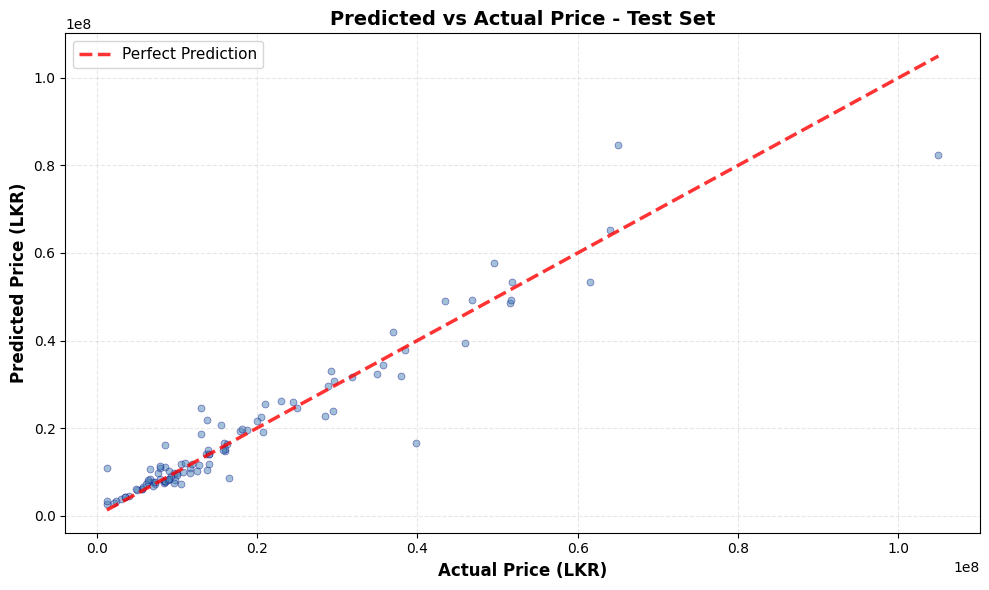

In [17]:
# Plot 1: Predicted vs Actual (Test Set)
print("\nGenerating predicted vs actual scatter plot...")

y_test_pred = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_test_pred, alpha=0.5, s=25, color="steelblue", edgecolors="navy", linewidth=0.5)

# Add perfect prediction line
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], "r--", lw=2.5, label="Perfect Prediction", alpha=0.8)

plt.xlabel("Actual Price (LKR)", fontsize=12, fontweight="bold")
plt.ylabel("Predicted Price (LKR)", fontsize=12, fontweight="bold")
plt.title("Predicted vs Actual Price - Test Set", fontsize=14, fontweight="bold")
plt.legend(fontsize=11, loc="upper left")
plt.grid(True, alpha=0.3, linestyle="--")
plt.tight_layout()
plt.savefig("predicted_vs_actual.png", dpi=300, bbox_inches="tight")
print("Saved: predicted_vs_actual.png")
plt.show()

In [18]:
# Evaluation Function & Results
def evaluate_model(model, X, y, dataset_name):
    y_pred = model.predict(X)
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    
    return {
        "Dataset": dataset_name,
        "R² Score": r2,
        "MAE": mae,
        "RMSE": rmse,
        "Sample Count": len(y)
    }

print("Evaluating model on train/val/test sets...\n")

results_train = evaluate_model(best_model, X_train, y_train, "Train")
results_val = evaluate_model(best_model, X_val, y_val, "Validation")
results_test = evaluate_model(best_model, X_test, y_test, "Test")

# Create and display results table
results_df = pd.DataFrame([results_train, results_val, results_test])
print("="*85)
print("EVALUATION RESULTS")
print("="*85)
print(results_df.to_string(index=False))
print("="*85)

Evaluating model on train/val/test sets...

EVALUATION RESULTS
   Dataset  R² Score          MAE         RMSE  Sample Count
     Train  0.966503 1.996576e+06 3.789324e+06           470
Validation  0.771775 6.393879e+06 1.488867e+07           101
      Test  0.917648 2.784024e+06 4.947821e+06           101


In [19]:
# Summary & Selected Hyperparameters
print("\n" + "="*60)
print("SELECTED HYPERPARAMETERS (CatBoost)")
print("="*60)
for param, value in catboost_params.items():
    print(f"{param:.<35} {value}")
print("="*60)

print("\n✓ Model training and evaluation complete!")
print("\nGenerated Outputs:")
print("  1. Evaluation Results Table (displayed above)")
print("  2. predicted_vs_actual.png")


SELECTED HYPERPARAMETERS (CatBoost)
iterations......................... 2000
learning_rate...................... 0.03
depth.............................. 6
l2_leaf_reg........................ 5
loss_function...................... RMSE
eval_metric........................ RMSE
random_seed........................ 42
verbose............................ 200

✓ Model training and evaluation complete!

Generated Outputs:
  1. Evaluation Results Table (displayed above)
  2. predicted_vs_actual.png


# SHAP Explainability Analysis

Use SHAP (SHapley Additive exPlanations) to explain the CatBoost model predictions:
- **Summary plot**: Shows feature importance and impact on predictions
- **Dependence plots**: How specific features affect predictions (mileage_km, year)
- **Waterfall plot**: Explains one individual prediction step-by-step

In [20]:
import shap
import warnings
warnings.filterwarnings('ignore')

print("Initializing SHAP TreeExplainer...")
# Create SHAP explainer using the trained CatBoost model
explainer = shap.TreeExplainer(best_model)

# Calculate SHAP values for test set
print("Computing SHAP values for test set (this may take a moment)...")
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"Number of test samples: {len(X_test)}")
print("✓ SHAP explainer initialized successfully\n")

Initializing SHAP TreeExplainer...
Computing SHAP values for test set (this may take a moment)...
SHAP values shape: (101, 7)
Number of test samples: 101
✓ SHAP explainer initialized successfully



Generating SHAP summary plot (bar)...
Saved: shap_summary_plot.png


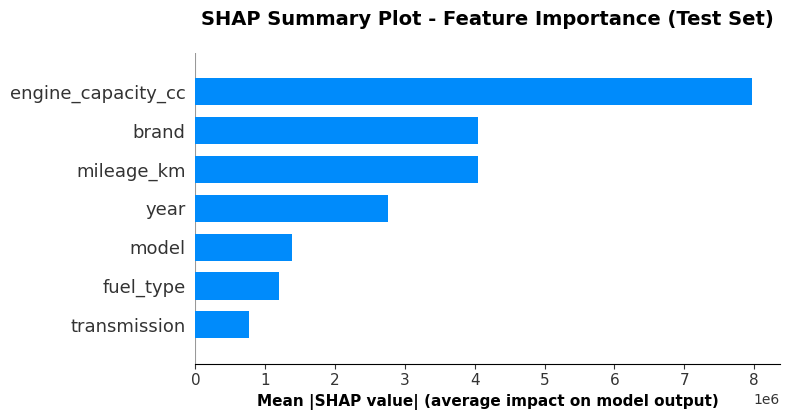


Interpretation: Features at the top have the highest average impact on predictions.
Longer bars = more important features for explaining price variations.



In [21]:
# Plot 1: SHAP Summary Plot (Mean Absolute SHAP values)
print("Generating SHAP summary plot (bar)...")

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("SHAP Summary Plot - Feature Importance (Test Set)", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("Mean |SHAP value| (average impact on model output)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_summary_plot.png", dpi=300, bbox_inches="tight")
print("Saved: shap_summary_plot.png")
plt.show()

print("\nInterpretation: Features at the top have the highest average impact on predictions.")
print("Longer bars = more important features for explaining price variations.\n")

Generating SHAP dependence plots...
Saved: shap_dependence_mileage.png


<Figure size 800x600 with 0 Axes>

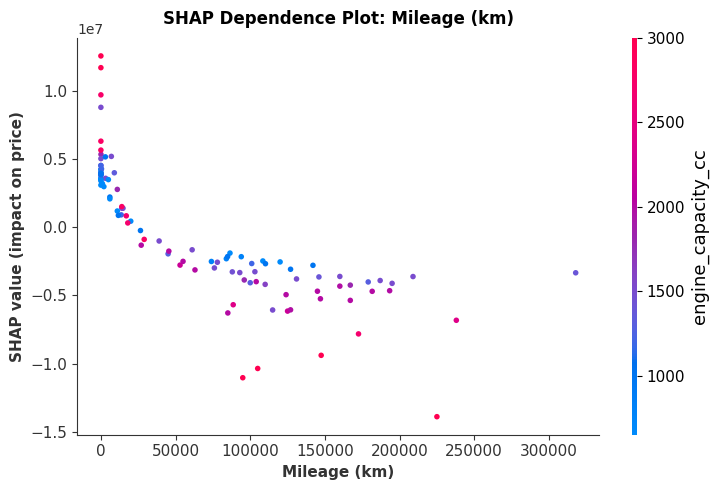

Saved: shap_dependence_year.png


<Figure size 800x600 with 0 Axes>

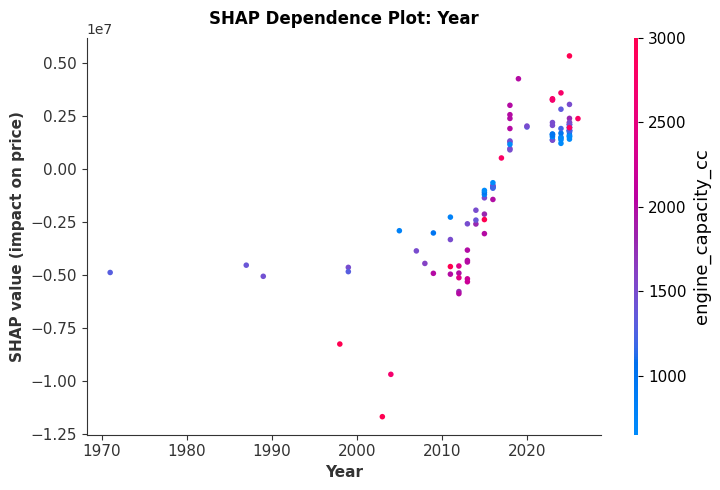


Interpretation:
- X-axis: Feature value (mileage or year)
- Y-axis: SHAP value (positive = increases price, negative = decreases price)
- Color: Related feature value (helps identify interactions)
- Higher mileage typically → lower SHAP value → lower predicted price
- Newer year (higher value) typically → higher SHAP value → higher predicted price



In [26]:
# Plot 2: SHAP Dependence Plots for mileage_km and year
print("Generating SHAP dependence plots...")

# Dependence plot for mileage_km
plt.figure(figsize=(8, 6))
shap.dependence_plot("mileage_km", shap_values, X_test, show=False)
plt.title("SHAP Dependence Plot: Mileage (km)", fontsize=12, fontweight="bold", pad=10)
plt.xlabel("Mileage (km)", fontsize=11, fontweight="bold")
plt.ylabel("SHAP value (impact on price)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_dependence_mileage.png", dpi=300, bbox_inches="tight")
print("Saved: shap_dependence_mileage.png")
plt.show()

# Dependence plot for year
plt.figure(figsize=(8, 6))
shap.dependence_plot("year", shap_values, X_test, show=False)
plt.title("SHAP Dependence Plot: Year", fontsize=12, fontweight="bold", pad=10)
plt.xlabel("Year", fontsize=11, fontweight="bold")
plt.ylabel("SHAP value (impact on price)", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("shap_dependence_year.png", dpi=300, bbox_inches="tight")
print("Saved: shap_dependence_year.png")
plt.show()

print("\nInterpretation:")
print("- X-axis: Feature value (mileage or year)")
print("- Y-axis: SHAP value (positive = increases price, negative = decreases price)")
print("- Color: Related feature value (helps identify interactions)")
print("- Higher mileage typically → lower SHAP value → lower predicted price")
print("- Newer year (higher value) typically → higher SHAP value → higher predicted price\n")

Generating SHAP waterfall plot for a single test sample...
Saved: shap_waterfall_plot.png


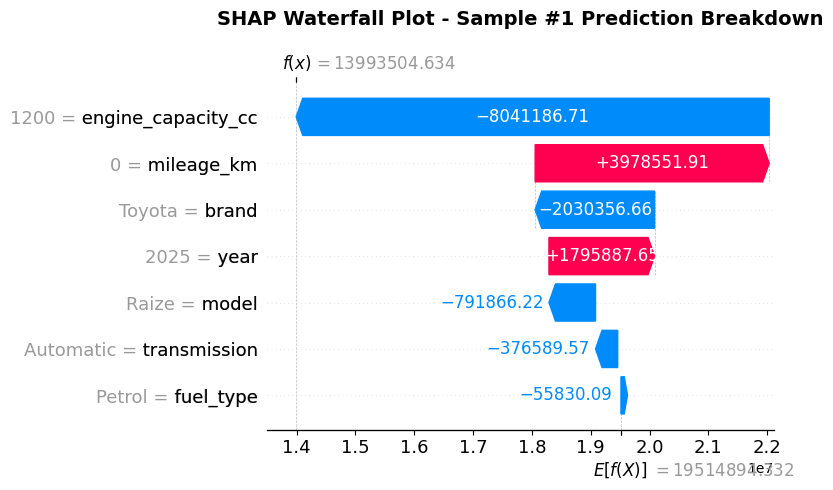


Sample #1 Details:
  Base prediction (model average): LKR 19,514,894
  Actual price: LKR 13,590,000
  Predicted price: LKR 13,993,505
  Prediction error: LKR 403,505

Interpretation:
  - Start at base value: LKR 19,514,894
  - Red features push prediction DOWN (decrease price)
  - Blue features push prediction UP (increase price)
  - Final prediction: LKR 13,993,505



In [27]:
# Plot 3: SHAP Waterfall Plot for One Test Sample
print("Generating SHAP waterfall plot for a single test sample...")

# Select a test sample (first one)
sample_index = 1

# Get base value (handle both scalar and array returns)
base_value = explainer.expected_value
if isinstance(base_value, (list, np.ndarray)):
    base_value = float(base_value[0]) if len(base_value) > 0 else float(base_value)
else:
    base_value = float(base_value)

sample_explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=base_value,
    data=X_test.iloc[sample_index].values,
    feature_names=X_test.columns.tolist()
)

plt.figure(figsize=(12, 8))
shap.waterfall_plot(sample_explanation, show=False)
plt.title(f"SHAP Waterfall Plot - Sample #{sample_index} Prediction Breakdown", fontsize=14, fontweight="bold", pad=20)
plt.tight_layout()
plt.savefig("shap_waterfall_plot.png", dpi=300, bbox_inches="tight")
print("Saved: shap_waterfall_plot.png")
plt.show()

# Print details about the sample
actual_price = y_test.iloc[sample_index]
predicted_price = best_model.predict(X_test.iloc[sample_index:sample_index+1])[0]

print(f"\nSample #{sample_index} Details:")
print(f"  Base prediction (model average): LKR {base_value:,.0f}")
print(f"  Actual price: LKR {actual_price:,.0f}")
print(f"  Predicted price: LKR {predicted_price:,.0f}")
print(f"  Prediction error: LKR {abs(predicted_price - actual_price):,.0f}")
print(f"\nInterpretation:")
print(f"  - Start at base value: LKR {base_value:,.0f}")
print(f"  - Red features push prediction DOWN (decrease price)")
print(f"  - Blue features push prediction UP (increase price)")
print(f"  - Final prediction: LKR {predicted_price:,.0f}\n")

In [ ]:
# Summary: SHAP Explainability Analysis Complete
print("="*70)
print("SHAP EXPLAINABILITY ANALYSIS SUMMARY")
print("="*70)
print("\n✓ Generated SHAP visualizations:")
print("  1. shap_summary_plot.png")
print("     → Shows average feature importance for explaining predictions")
print("\n  2. shap_dependence_mileage.png")
print("     → Shows how mileage affects price predictions")
print("\n  3. shap_dependence_year.png")
print("     → Shows how year affects price predictions")
print("\n  4. shap_waterfall_plot.png")
print("     → Explains a single prediction step-by-step")
print("     → Shows which features pushed the prediction up or down")
print("\n" + "="*70)
print("\nKey Insights from SHAP:")
print("  • SHAP values show each feature's contribution to the prediction")
print("  • Positive SHAP = feature increases predicted price")
print("  • Negative SHAP = feature decreases predicted price")
print("  • Summary plot ranks features by average |SHAP value|")
print("  • Waterfall plot explains individual predictions")
print("="*70 + "\n")

SHAP EXPLAINABILITY ANALYSIS SUMMARY

✓ Generated SHAP visualizations:
  1. shap_summary_plot.png
     → Shows average feature importance for explaining predictions

  2. shap_dependence_plots.png
     → Shows how mileage and year affect price predictions
     → Red points indicate high values, blue for low values

  3. shap_waterfall_plot.png
     → Explains a single prediction step-by-step
     → Shows which features pushed the prediction up or down


Key Insights from SHAP:
  • SHAP values show each feature's contribution to the prediction
  • Positive SHAP = feature increases predicted price
  • Negative SHAP = feature decreases predicted price
  • Summary plot ranks features by average |SHAP value|
  • Waterfall plot explains individual predictions



In [25]:
import joblib

joblib.dump(best_model, "catboost_model.pkl")
joblib.dump(X.columns.tolist(), "feature_columns.pkl")
joblib.dump(CAT_FEATURES, "cat_features.pkl")


['cat_features.pkl']